In [2]:
from config_features import FEATURES, LABEL
import pandas as pd
from sklearn.preprocessing import StandardScaler

# Gemeinsames Dataset laden
df = pd.read_csv('1_delta_replaced_data.csv')


In [3]:
df = df.iloc[:6660]

In [4]:
# 1. Label umwandeln: 'attack' → 1, 'benign' → 0
df[LABEL] = df[LABEL].map({'attack': 1, 'benign': 0})

# 2. Features und Label auswählen
X = df[FEATURES]
y = df[LABEL]

# 3. Features skalieren (Scaler auf komplettes Dataset)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [5]:
df.head(-1)

,timestamp,ase_spec,br_immed_spec,br_indirect_spec,br_mis_pred,br_pred,br_return_spec,branch-load-misses,branch-loads,branch-misses,...,writeback_writeback_single_inode,writeback_writeback_single_inode_start,writeback_writeback_start,writeback_writeback_wait,writeback_writeback_wait_iff_congested,writeback_writeback_wake_background,writeback_writeback_write_inode,writeback_writeback_written,attack,Label
0,2025-07-22T18:00:00,842.0,534639.0,114176.0,14852.0,648716.0,95435.0,15470.0,657359.0,16248.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,benign,0
1,2025-07-22T18:00:10,830.0,530504.0,113038.0,14845.0,643445.0,94416.0,14958.0,649089.0,15080.0,...,2.0,2.0,12.0,0.0,0.0,0.0,2.0,12.0,benign,0
2,2025-07-22T18:00:20,775.0,530791.0,113318.0,15235.0,644009.0,94677.0,16126.0,678009.0,14637.0,...,1.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,benign,0
3,2025-07-22T18:00:30,895.0,533606.0,113935.0,14633.0,647442.0,95136.0,15474.0,646697.0,14399.0,...,0.0,0.0,-2.0,0.0,0.0,0.0,-1.0,-2.0,benign,0
4,2025-07-22T18:00:40,822.0,536215.0,114003.0,15363.0,650120.0,95225.0,14512.0,640024.0,14608.0,...,-1.0,-1.0,0.0,0.0,0.0,0.0,0.0,0.0,benign,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6654,2025-07-23T12:29:00,830.0,525477.0,112310.0,14556.0,637690.0,93777.0,18721.0,969909.0,14572.0,...,1.0,1.0,3.0,0.0,0.0,0.0,2.0,3.0,synonymousflood,1
6655,2025-07-23T12:29:10,769.0,536543.0,114535.0,15123.0,650979.0,95704.0,15547.0,655176.0,15006.0,...,-2.0,-2.0,-6.0,0.0,0.0,0.0,-2.0,-6.0,synonymousflood,1
6656,2025-07-23T12:29:20,795.0,536401.0,114871.0,15223.0,651172.0,95975.0,15452.0,649059.0,18670.0,...,-1.0,-1.0,3.0,0.0,0.0,0.0,0.0,3.0,synonymousflood,1
6657,2025-07-23T12:29:30,845.0,541522.0,115883.0,15465.0,657305.0,96788.0,15265.0,659025.0,15071.0,...,0.0,0.0,-2.0,0.0,0.0,0.0,0.0,-2.0,synonymousflood,1


In [5]:
import numpy as np

def create_sequences(X, y, window_size=5):
    X_seq = []
    y_seq = []
    for i in range(len(X) - window_size + 1):
        label_window = y[i:i+window_size]
        # Nur wenn alle Labels im Fenster gleich sind
        if np.all(label_window == label_window[0]):
            X_seq.append(X[i:i+window_size])
            y_seq.append(label_window[0])
    return np.array(X_seq), np.array(y_seq)

# Anwendung auf deine Daten (jetzt mit window_size=5)
X_sequences, y_sequences = create_sequences(X_scaled, y.values, window_size=5)


In [6]:
print(X_sequences.shape)  # (Anzahl Fenster, 10, Anzahl Features)
print(y_sequences.shape)  # (Anzahl Fenster,)


(6548, 5, 17)
(6548,)


In [7]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# Function to create a stacked LSTM model
def create_lstm_model(num_features):
    model = Sequential([
        # First LSTM layer (returns full sequences for stacking)
        LSTM(50, input_shape=(5, num_features), return_sequences=True),
        Dropout(0.2),  # Dropout to prevent overfitting
        # Second LSTM layer (only returns final output)
        LSTM(15),
        Dropout(0.2),  # Additional regularization
        # Output layer for binary classification
        Dense(1, activation='sigmoid')
    ])
    
    # Compile model with binary crossentropy loss and accuracy metric
    model.compile(
        loss='binary_crossentropy',
        optimizer='adam',
        metrics=['accuracy']
    )
    return model

# Create model with number of selected input features
model = create_lstm_model(len(FEATURES))

# Print model summary
model.summary()

# Print number of selected features
print(len(FEATURES))

2025-07-31 04:45:28.552127: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-07-31 04:45:28.552779: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-07-31 04:45:28.555644: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-07-31 04:45:28.561873: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1753929928.572351 3696461 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1753929928.57

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 5, 50)          │        13,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 5, 50)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 15)             │         3,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 15)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            16 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,576 (68.66 KB)

 Trainable params: 17,576 (68.66 KB)

 Non-trainable params: 0 (0.00 B)

17


In [8]:
history = model.fit(
    X_sequences, y_sequences,
    epochs=25,         # Anzahl der Durchläufe, du kannst anpassen
    batch_size=64,     # Größe der Trainingsbatches (vorerst Standard)
#    validation_split=0.2  # 20% der Daten werden für Validierung verwendet
)


Epoch 1/25
103/103 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8553 - loss: 0.4945
Epoch 2/25
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9581 - loss: 0.1710
Epoch 3/25
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9587 - loss: 0.1617
Epoch 4/25
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9583 - loss: 0.1380
Epoch 5/25
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9591 - loss: 0.1275
Epoch 6/25
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9557 - loss: 0.1255
Epoch 7/25
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9575 - loss: 0.1102
Epoch 8/25
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9658 - loss: 0.0929
Epoch 9/25
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9611 - loss: 0.0977
Epoch 10/25
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9602 - loss: 0.0936
Epoch 11/25
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9660 - loss: 0.0798
Epoch 12/25
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

In [9]:
from sklearn.metrics import accuracy_score, classification_report

# 1. Vorhersage auf allen Sequenzdaten machen
y_pred_prob = model.predict(X_sequences)

# 2. Wahrscheinlichkeiten in Klassenlabels umwandeln
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

# 3. Genauigkeit und Klassifikationsbericht berechnen
accuracy = accuracy_score(y_sequences, y_pred)
report = classification_report(y_sequences, y_pred)

# 4. Ausgabe
print(f"Genauigkeit: {accuracy:.4f}")
print(report)


205/205 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Genauigkeit: 0.9853
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      5673
           1       0.97      0.92      0.94       875

    accuracy                           0.99      6548
   macro avg       0.98      0.96      0.97      6548
weighted avg       0.99      0.99      0.99      6548



205/205 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
[[5650   23]
 [  73  802]]


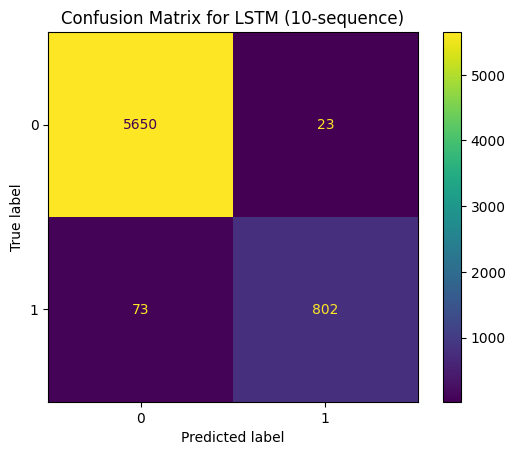

In [10]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import os

# 1. Vorhersage (Klassenzuordnung) für alle Sequenzen
y_pred_seq = (model.predict(X_sequences) > 0.5).astype(int).flatten()

# 2. Confusion Matrix berechnen
cm = confusion_matrix(y_sequences, y_pred_seq)

# 3. Confusion Matrix als Zahlen ausgeben
print(cm)

# 4. Confusion Matrix als Grafik anzeigen
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title('Confusion Matrix for LSTM (10-sequence)')

# 5. Grafik speichern
output_dir = "/home/yannic/Desktop/Uni/Semester8_Regensburg/Bachelorarbeit/graffics_for_BA/feature_plots"
filename = "confusion_matrix.png"
filepath = os.path.join(output_dir, filename)
plt.savefig(filepath, dpi=300)
plt.show()


In [11]:
import pandas as pd
import numpy as np

window_size = 5

# 1. Das ursprüngliche Attack-Array holen (aus dem vollständigen DataFrame)
attack_array = df["attack"].values   # Hier ist df dein gesamtes DataFrame
y_array = y.values                  # Die Labels, wie vorher erzeugt

# 2. Für jedes Fenster mit konstantem Label: Attack-Typ des ersten Elements speichern
attack_seq = np.array([
    attack_array[i]
    for i in range(len(attack_array) - window_size + 1)
    if np.all(y_array[i:i+window_size] == y_array[i])
])

# 3. DataFrame kombinieren: Wahres Label, Vorhersage, Attack-Typ
df_summary = pd.DataFrame({
    "y_true": y_sequences,
    "y_pred": y_pred_seq,
    "attack": attack_seq
})

# 4. Falsch erkannte Angriffe herausfiltern (eigentlich Angriff, aber Modell sagt "keine Attacke")
misclassified = df_summary[(df_summary["y_true"] == 1) & (df_summary["y_pred"] == 0)]

# 5. Anzahl falscher und aller Angriffe je Typ zählen
misclassified_counts = misclassified["attack"].value_counts()
total_counts = df_summary[df_summary["y_true"] == 1]["attack"].value_counts()

# 6. Zusammenfassen in eine Übersichtstabelle
summary = pd.DataFrame({
    "misclassified": misclassified_counts,
    "total": total_counts
}).fillna(0).astype(int)

# 7. Tabelle ausgeben (sortiert nach den falsch Erkannten)
print(summary.sort_values("misclassified", ascending=False))


                  misclassified  total
attack                                
slowloris                    46    142
aggressivescan               14     56
osfingerprinting             13     56
icmpflood                     0    173
portscan                      0     73
synonymousflood               0    111
tcpflood                      0    134
udpflood                      0    130


205/205 ━━━━━━━━━━━━━━━━━━━━ 0s 973us/step
205/205 ━━━━━━━━━━━━━━━━━━━━ 0s 894us/step
205/205 ━━━━━━━━━━━━━━━━━━━━ 0s 887us/step
205/205 ━━━━━━━━━━━━━━━━━━━━ 0s 897us/step
205/205 ━━━━━━━━━━━━━━━━━━━━ 0s 945us/step
205/205 ━━━━━━━━━━━━━━━━━━━━ 0s 996us/step
205/205 ━━━━━━━━━━━━━━━━━━━━ 0s 904us/step
205/205 ━━━━━━━━━━━━━━━━━━━━ 0s 943us/step
205/205 ━━━━━━━━━━━━━━━━━━━━ 0s 995us/step
205/205 ━━━━━━━━━━━━━━━━━━━━ 0s 982us/step
205/205 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
205/205 ━━━━━━━━━━━━━━━━━━━━ 0s 948us/step
205/205 ━━━━━━━━━━━━━━━━━━━━ 0s 989us/step
205/205 ━━━━━━━━━━━━━━━━━━━━ 0s 983us/step
205/205 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
205/205 ━━━━━━━━━━━━━━━━━━━━ 0s 953us/step
205/205 ━━━━━━━━━━━━━━━━━━━━ 0s 936us/step
205/205 ━━━━━━━━━━━━━━━━━━━━ 0s 900us/step


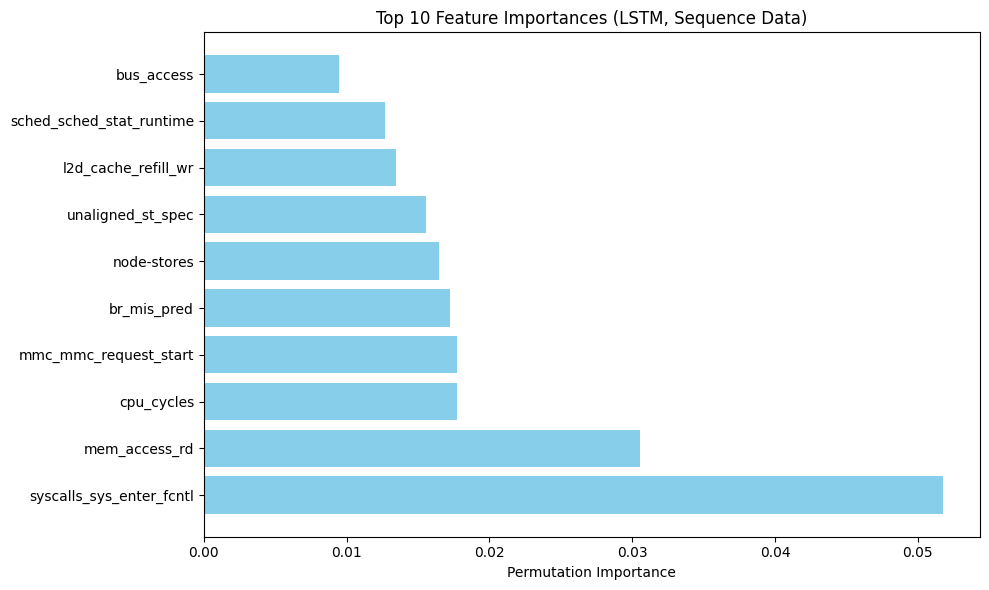

In [12]:
import numpy as np
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import os

# Annahme: model, X_sequences, y_sequences, FEATURES sind schon definiert

# 1. Baseline-Genauigkeit auf den Sequenzdaten
y_pred_seq = model.predict(X_sequences)
original_acc = accuracy_score(y_sequences, (y_pred_seq > 0.5).astype(int))

feature_importances = []
for i in range(X_sequences.shape[2]):
    X_test_perm = X_sequences.copy()
    # Permutiere das i-te Merkmal (über alle Zeitfenster und alle Zeitpunkte!)
    np.random.shuffle(X_test_perm[:, :, i])
    y_pred_perm = model.predict(X_test_perm)
    perm_acc = accuracy_score(y_sequences, (y_pred_perm > 0.5).astype(int))
    feature_importances.append(original_acc - perm_acc)

# 2. Top-10-Merkmale finden
indices_top10 = np.argsort(feature_importances)[-10:][::-1]
top10_features = [FEATURES[i] for i in indices_top10]
top10_importances = [feature_importances[i] for i in indices_top10]

# 3. Balkendiagramm für die Top-10
plt.figure(figsize=(10, 6))
plt.barh(top10_features, top10_importances, color='skyblue')
plt.xlabel('Permutation Importance')
plt.title('Top 10 Feature Importances (LSTM, Sequence Data)')
plt.tight_layout()
output_dir = "/home/yannic/Desktop/Uni/Semester8_Regensburg/Bachelorarbeit/graffics_for_BA/feature_plots"
filename = "feature_importances_lstm.png"
filepath = os.path.join(output_dir, filename)
plt.savefig(filepath, dpi=300)
plt.show()


In [13]:
from tensorflow.keras.models import load_model
import joblib

model.save('lstm_model.keras')
joblib.dump(scaler, "scaler.pkl")


['scaler1.pkl']